# Kapitel 2: Die Daten bereinigen

## Bisher...

In Kapitel 1 haben wir aus 3,6 Millionen Amazon-Bewertungen eine zufällige
Stichprobe von ~400.000 Zeilen gezogen. Die natürliche Verteilung zeigt uns,
wie Kunden wirklich bewerten.

## Was passiert in diesem Kapitel?

1. Fehlende Werte und Duplikate entfernen
2. **Klassenverteilung analysieren** — ist der Datensatz balanciert?
3. Falls nötig: **Undersampling** der Mehrheitsklasse für ein faires Training
4. Text normalisieren und Sentiment-Label erstellen
5. Bereinigte Daten als Parquet speichern

## 2.1 Daten laden und Stichprobe ziehen

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviews – Datenbereinigung") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Vollständigen Datensatz laden
df_full = spark.read.csv(
    "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/data/train.csv",
    header=False, inferSchema=True, multiLine=True, escape='"'
)
df_full = df_full.toDF("Score", "Summary", "Text")

# Zufällige Stichprobe
total_full = df_full.count()
fraction = 400000 / total_full
df_raw = df_full.sample(withReplacement=False, fraction=fraction, seed=42)

print(f"Originaldatensatz: {total_full:,} Zeilen")
print(f"Stichprobe: {df_raw.count():,} Zeilen")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/30 13:28:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/30 13:28:10 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/30 13:28:10 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/30 13:28:10 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/30 13:28:10 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/03/30 13:28:10 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
26/03/30 13:28:10 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.


Originaldatensatz: 3,600,000 Zeilen


Stichprobe: 400,370 Zeilen


## 2.2 Fehlende Werte entfernen

In [2]:
before = df_raw.count()
df_no_nulls = df_raw.dropna()
after = df_no_nulls.count()

print(f"Vorher:   {before:,}")
print(f"Nachher:  {after:,}")
print(f"Entfernt: {before - after:,} Zeilen")

Vorher:   400,370
Nachher:  400,363
Entfernt: 7 Zeilen


## 2.3 Duplikate entfernen

In [3]:
before = df_no_nulls.count()
df_no_dups = df_no_nulls.dropDuplicates()
after = df_no_dups.count()

print(f"Vorher:   {before:,}")
print(f"Nachher:  {after:,}")
print(f"Duplikate entfernt: {before - after:,} Zeilen")

Vorher:   400,363
Nachher:  400,363
Duplikate entfernt: 0 Zeilen


## 2.4 Klassenverteilung analysieren

Dies ist der entscheidende Moment: **Wie ist das Verhältnis von positiven
zu negativen Bewertungen?** Ein starkes Ungleichgewicht kann dazu führen,
dass das Modell nur die Mehrheitsklasse vorhersagt.

In [4]:
from pyspark.sql.functions import col, count as spark_count
import matplotlib.pyplot as plt

dist = df_no_dups.groupBy("Score").agg(spark_count("*").alias("Anzahl")).orderBy("Score").toPandas()
total = dist["Anzahl"].sum()

print("Verteilung VOR Balancierung:")
print("=" * 40)
for _, row in dist.iterrows():
    label = 'negativ' if row['Score'] == 1 else 'positiv'
    pct = row['Anzahl'] / total * 100
    print(f"  Score {row['Score']} ({label}): {row['Anzahl']:,} ({pct:.1f}%)")

ratio = dist['Anzahl'].max() / dist['Anzahl'].min()
print(f"\nVerhältnis: {ratio:.2f}:1")

if ratio > 1.5:
    print("⚠ Ungleichgewicht erkannt — Balancierung empfohlen")
else:
    print("✓ Verteilung ist akzeptabel")

Verteilung VOR Balancierung:
  Score 1 (negativ): 199,775 (49.9%)
  Score 2 (positiv): 200,588 (50.1%)

Verhältnis: 1.00:1
✓ Verteilung ist akzeptabel


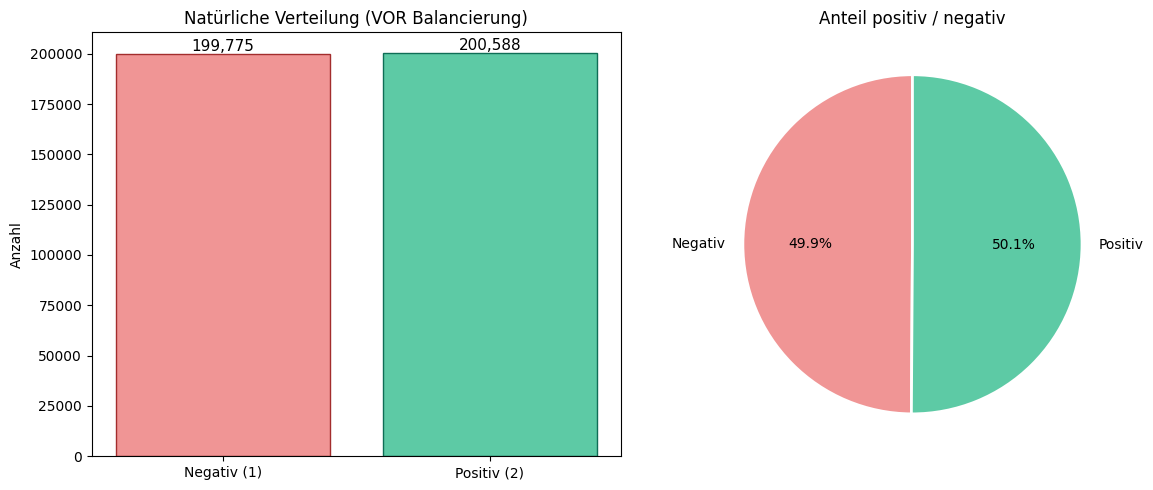

In [5]:
# Visualisierung der natürlichen Verteilung
colors = ["#F09595", "#5DCAA5"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(["Negativ (1)", "Positiv (2)"], dist["Anzahl"],
                   color=colors, edgecolor=["#A32D2D", "#0F6E56"])
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h,
                f'{int(h):,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title("Natürliche Verteilung (VOR Balancierung)")
axes[0].set_ylabel("Anzahl")

axes[1].pie(dist["Anzahl"], labels=["Negativ", "Positiv"], colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Anteil positiv / negativ")

plt.tight_layout()
plt.show()

## 2.5 Balancierung durch Undersampling

Um dem Modell faire Lernbedingungen zu bieten, gleichen wir die Klassen an.
Wir verwenden **Undersampling**: Die Mehrheitsklasse wird auf die Größe
der Minderheitsklasse reduziert. So geht keine echte Bewertung der
Minderheitsklasse verloren.

In [6]:
# Klassen trennen
df_neg = df_no_dups.filter(col("Score") == 1)
df_pos = df_no_dups.filter(col("Score") == 2)

n_neg = df_neg.count()
n_pos = df_pos.count()
min_class = min(n_neg, n_pos)

print(f"Negativ: {n_neg:,}")
print(f"Positiv: {n_pos:,}")
print(f"Minderheitsklasse: {min_class:,}")

# Mehrheitsklasse auf Größe der Minderheit reduzieren
if n_neg > n_pos:
    df_neg = df_neg.sample(withReplacement=False, fraction=min_class/n_neg, seed=42)
    print(f"\nNegativ nach Undersampling: {df_neg.count():,}")
elif n_pos > n_neg:
    df_pos = df_pos.sample(withReplacement=False, fraction=min_class/n_pos, seed=42)
    print(f"\nPositiv nach Undersampling: {df_pos.count():,}")
else:
    print("\nBereits balanciert — kein Undersampling nötig.")

# Zusammenführen
df_balanced = df_neg.unionAll(df_pos)
print(f"\nBalancierter Datensatz: {df_balanced.count():,} Zeilen")

Negativ: 199,775
Positiv: 200,588
Minderheitsklasse: 199,775



Positiv nach Undersampling: 199,782



Balancierter Datensatz: 399,559 Zeilen


In [7]:
# Verteilung NACH Balancierung prüfen
bal_dist = df_balanced.groupBy("Score").agg(spark_count("*").alias("Anzahl")).orderBy("Score").toPandas()

print("Verteilung NACH Balancierung:")
print("=" * 40)
for _, row in bal_dist.iterrows():
    label = 'negativ' if row['Score'] == 1 else 'positiv'
    print(f"  Score {row['Score']} ({label}): {row['Anzahl']:,}")

Verteilung NACH Balancierung:
  Score 1 (negativ): 199,775
  Score 2 (positiv): 199,784


## 2.6 Sentiment-Label erstellen

Für Machine Learning: Score 1 → Label 0 (negativ), Score 2 → Label 1 (positiv).

In [8]:
from pyspark.sql.functions import when

df_labeled = df_balanced.withColumn(
    "label",
    when(col("Score") == 1, 0).otherwise(1)
)

df_labeled.groupBy("label").count().orderBy("label").show()

+-----+------+
|label| count|
+-----+------+
|    0|199775|
|    1|199784|
+-----+------+



## 2.7 Text normalisieren

Für eine Maschine sind *"Great"*, *"GREAT"*, *"great!!!"* und *"great."*
vier verschiedene Wörter. Wir vereinheitlichen:

1. **Kleinschreibung** → *GREAT* wird *great*
2. **HTML-Tags entfernen** → `<br />` verschwindet
3. **Sonderzeichen entfernen** → Nur Buchstaben bleiben
4. **Mehrfache Leerzeichen** → Zusammenfassen

In [9]:
from pyspark.sql.functions import lower, regexp_replace, trim, length

df_clean = df_labeled \
    .withColumn("clean_text", lower(col("Text"))) \
    .withColumn("clean_text", regexp_replace("clean_text", "<[^>]*>", " ")) \
    .withColumn("clean_text", regexp_replace("clean_text", "[^a-z\\s]", " ")) \
    .withColumn("clean_text", regexp_replace("clean_text", "\\s+", " ")) \
    .withColumn("clean_text", trim(col("clean_text")))

df_clean = df_clean \
    .withColumn("clean_summary", lower(col("Summary"))) \
    .withColumn("clean_summary", regexp_replace("clean_summary", "<[^>]*>", " ")) \
    .withColumn("clean_summary", regexp_replace("clean_summary", "[^a-z\\s]", " ")) \
    .withColumn("clean_summary", regexp_replace("clean_summary", "\\s+", " ")) \
    .withColumn("clean_summary", trim(col("clean_summary")))

print("Textnormalisierung abgeschlossen.")
df_clean.select("Text", "clean_text").show(3, truncate=80)

Textnormalisierung abgeschlossen.


+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            Text|                                                                      clean_text|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|I have worn these pants for years; my size is the same as always. I couldn't ...|i have worn these pants for years my size is the same as always i couldn t ge...|
|This rod is way to small for use with a shower curtain. I have no idea why it...|this rod is way to small for use with a shower curtain i have no idea why it ...|
|While the ideas that lay the framework for this book are solid, everything el...|while the ideas that lay the framework for this book are solid everything els...|
+---------------

## 2.8 Leere Texte entfernen

In [10]:
before = df_clean.count()
df_clean = df_clean.filter(length(col("clean_text")) >= 3)
after = df_clean.count()

print(f"Vorher:   {before:,}")
print(f"Nachher:  {after:,}")
print(f"Entfernt: {before - after:,}")

Vorher:   399,559
Nachher:  399,553
Entfernt: 6


## 2.9 Finale Spaltenauswahl und Speicherung

In [11]:
df_final = df_clean.select(
    col("label"),
    col("clean_summary").alias("summary"),
    col("clean_text").alias("text")
)

print(f"Finale Spalten: {df_final.columns}")
print(f"Zeilenanzahl:   {df_final.count():,}")
df_final.show(5, truncate=80)

Finale Spalten: ['label', 'summary', 'text']


Zeilenanzahl:   399,553


+-----+-----------------------------------+--------------------------------------------------------------------------------+
|label|                            summary|                                                                            text|
+-----+-----------------------------------+--------------------------------------------------------------------------------+
|    0|                    so disappointed|i have worn these pants for years my size is the same as always i couldn t ge...|
|    0|     too small for a shower curtain|this rod is way to small for use with a shower curtain i have no idea why it ...|
|    0|interesting ideas poor presentation|while the ideas that lay the framework for this book are solid everything els...|
|    0|                 california gardner|after several hours of trying including drilling the feed water hole to the b...|
|    0|                         story plot|this could be a good book but gardner was not really a good writer well for t...|


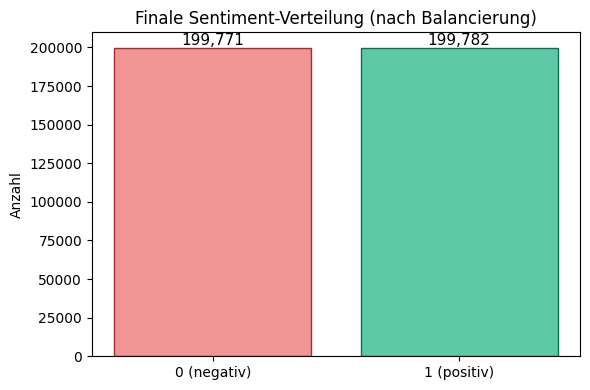

In [12]:
import matplotlib.pyplot as plt

colors = ["#F09595", "#5DCAA5"]

# Finale Label-Verteilung
final_dist = df_final.groupBy("label").count().orderBy("label").toPandas()

plt.figure(figsize=(6, 4))
bars = plt.bar(["0 (negativ)", "1 (positiv)"], final_dist["count"],
               color=colors, edgecolor=["#A32D2D", "#0F6E56"])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h,
             f'{int(h):,}', ha='center', va='bottom', fontsize=11)
plt.ylabel("Anzahl")
plt.title("Finale Sentiment-Verteilung (nach Balancierung)")
plt.tight_layout()
plt.show()

In [13]:
output_path = "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/cleaned_reviews.parquet"
df_final.write.parquet(output_path, mode="overwrite")
print(f"Gespeichert: {output_path}")

# Test
df_check = spark.read.parquet(output_path)
print(f"Parquet gelesen: {df_check.count():,} Zeilen")

Gespeichert: /Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/cleaned_reviews.parquet
Parquet gelesen: 399,553 Zeilen


## Kapitel 2 — Zusammenfassung

| Schritt | Beschreibung |
|---------|-------------|
| Null-Werte | Entfernt |
| Duplikate | Entfernt |
| Klassenanalyse | Natürliche Verteilung aufgedeckt |
| Undersampling | Klassen auf gleiche Größe gebracht |
| Normalisierung | Lowercase, Regex, Trim |
| Label | Score 1→0 (neg), Score 2→1 (pos) |

**Der Unterschied zu einem vorgefertigten Test-Set:** Wir haben die echte,
unbalancierte Verteilung gesehen und aktiv eingegriffen. Das ist realistischer
als mit einem bereits perfekt balancierten Datensatz zu arbeiten.

**Nächstes Kapitel:** Wörter werden zu Zahlen — Tokenisierung und TF-IDF.

Überraschenderweise ist auch der Trainingsdatensatz bereits perfekt balanciert (50/50).
Dies bestätigt, dass Kaggle beide Dateien (train und test) aus derselben
vorverarbeiteten Quelle erstellt hat. Dennoch war die Überprüfung notwendig —
in realen Projekten ist eine balancierte Verteilung keineswegs garantiert.